# Discussion 1 Assignment

Alexander Zhang  
alexacz1@uci.edu

## Setup
Load dependencies and set up environment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
import zipfile

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay
sns.set_theme(style="whitegrid", palette="muted")

In [3]:
def load_diabetes_readmission_data() -> pd.DataFrame:
    url = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"
    zip_filepath = "diabetes_readmission.zip"
    extract_folder = "diabetes_data_extracted"
    
    if not os.path.exists(zip_filepath):
        print(f"Downloading dataset...")
        r = requests.get(url)
        with open(zip_filepath, "wb") as f:
            f.write(r.content)
            
    with zipfile.ZipFile(zip_filepath, "r") as zip_ref:
        zip_ref.extractall(extract_folder)

    csv_path = None
    for root, dirs, files in os.walk(extract_folder):
        for file in files:
            if file.lower() == "diabetic_data.csv":
                csv_path = os.path.join(root, file)
                break
    
    if csv_path:
        print(f"Found file at: {csv_path}")
        return pd.read_csv(csv_path)
    else:
        raise FileNotFoundError("Could not find diabetic_data.csv in the extracted files.")

df = load_diabetes_readmission_data()
print(f"Success! Data loaded with {df.shape[0]} rows.")

Found file at: diabetes_data_extracted/diabetic_data.csv
Success! Data loaded with 101766 rows.


## Data Summarization
We are now going to summarize the data and preprocess it in a simple manner.  
It will be framed as a binary classification problem: Did the patient get readmitted in less than 30 days?  
We will use 1 for Yes (Early Readmission), 0 = No (or readmitted after 30 days).  
The data chosen will be a few intuitive, fully-populated numeric columns.

In [4]:
print("\n--- DATA SUMMARIZATION ---")
print(f"Total number of patients/records: {len(df)}")
print(f"Total number of variables: {df.shape[1]}")

df['target'] = (df['readmitted'] == '<30').astype(int)
print("\nTarget Variable Distribution (0 = No Early Readmission, 1 = Early Readmission):")
print(df['target'].value_counts(normalize=True) * 100)

features = [
    'time_in_hospital', 
    'num_lab_procedures', 
    'num_medications', 
    'number_diagnoses'
]

X = df[features]
y = df['target']


--- DATA SUMMARIZATION ---
Total number of patients/records: 101766
Total number of variables: 50

Target Variable Distribution (0 = No Early Readmission, 1 = Early Readmission):
target
0    88.840084
1    11.159916
Name: proportion, dtype: float64


## Visualization
First we will plot a histogram or density of time in hospital by the target.
Second plot will be a scatter plot of lab procedures versus medications.


Generating Visualizations...


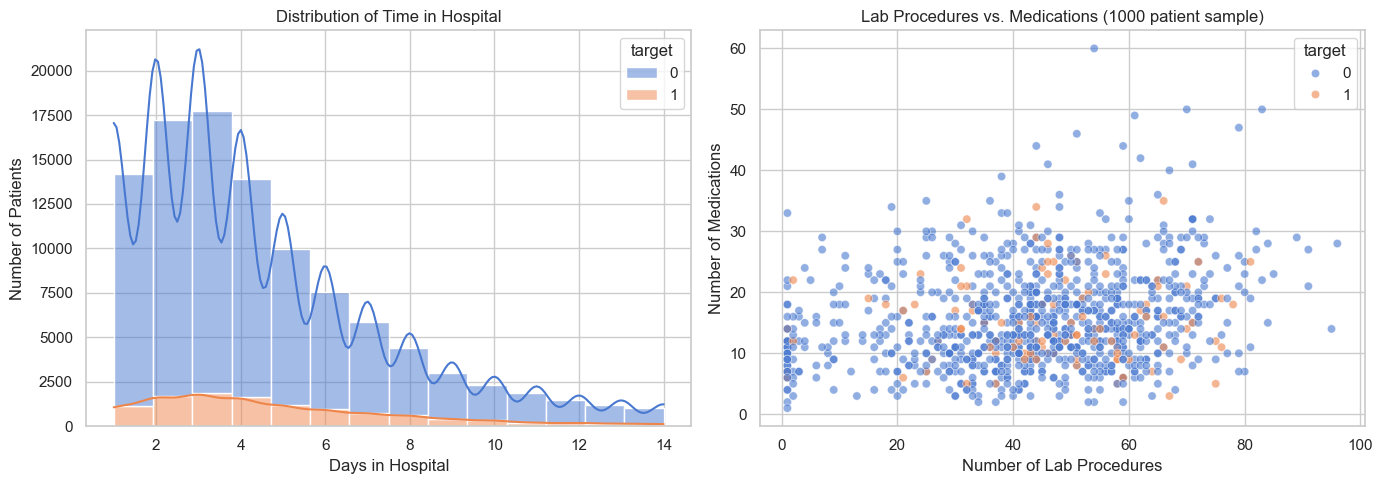

In [5]:
print("\nGenerating Visualizations...")
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='time_in_hospital', hue='target', bins=14, kde=True, multiple="stack")
plt.title("Distribution of Time in Hospital")
plt.xlabel("Days in Hospital")
plt.ylabel("Number of Patients")

plt.subplot(1, 2, 2)
sample_df = df.sample(1000, random_state=42)
sns.scatterplot(data=sample_df, x='num_lab_procedures', y='num_medications', hue='target', alpha=0.6)
plt.title("Lab Procedures vs. Medications (1000 patient sample)")
plt.xlabel("Number of Lab Procedures")
plt.ylabel("Number of Medications")

plt.tight_layout()
plt.show()

## Data Prep for ML  
80/20 training/test split for the data. Also scaling it so all features are treated fairly regardless of native units.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Machine Learning Methods

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [8]:
models = {
    "Method 1: Logistic Regression": LogisticRegression(random_state=42),
    "Method 2: Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Method 3: Random Forest": RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42),
    "Method 4: Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
    "Method 5: K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

Fit the model, predict on test, evaluate, and then plot ROC Curve.


--- ML MODEL EVALUATION ---
Method 1: Logistic Regression
  -> Accuracy: 0.8884 (Percentage of correct predictions)
  -> ROC AUC:  0.5650 (Ability to distinguish classes)
Method 2: Decision Tree
  -> Accuracy: 0.8883 (Percentage of correct predictions)
  -> ROC AUC:  0.5595 (Ability to distinguish classes)
Method 3: Random Forest
  -> Accuracy: 0.8884 (Percentage of correct predictions)
  -> ROC AUC:  0.5696 (Ability to distinguish classes)
Method 4: Gradient Boosting
  -> Accuracy: 0.8884 (Percentage of correct predictions)
  -> ROC AUC:  0.5723 (Ability to distinguish classes)
Method 5: K-Nearest Neighbors
  -> Accuracy: 0.8796 (Percentage of correct predictions)
  -> ROC AUC:  0.5071 (Ability to distinguish classes)


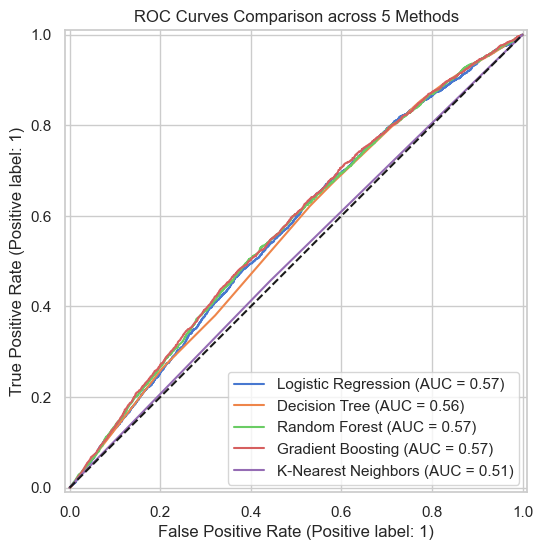

In [9]:
print("\n--- ML MODEL EVALUATION ---")
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    print(f"{name}")
    print(f"  -> Accuracy: {acc:.4f} (Percentage of correct predictions)")
    print(f"  -> ROC AUC:  {auc:.4f} (Ability to distinguish classes)")
    
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name.split(":")[1].strip())

plt.title("ROC Curves Comparison across 5 Methods")
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.show()